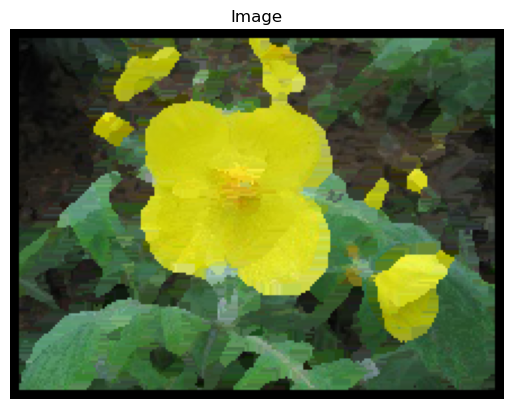

In [1]:
#1 gray 2 7*7 10*10 3 0-255 256 4 640-63 64-127 
# 3 10 0-63 99 
# 4 count 5 dst = result

import cv2
import numpy as np
img = cv2.imread('image00.jpg', 1)
imgInfo = img.shape
height = imgInfo[0]
width = imgInfo[1]
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
dst = np.zeros((height,width,3),np.uint8)
for i in range(4,height-4):
    for j in range(4,width-4):
        array1 = np.zeros(8,np.uint8)
        for m in range(-4,4):
            for n in range(-4,4):
                p1 = int(gray[i+m,j+n]/32)
                array1[p1] = array1[p1]+1
        currentMax = array1[0]
        l = 0
        for k in range(0,8):
            if currentMax<array1[k]:
                currentMax = array1[k]
                l = k
        # 简化 均值
        for m in range(-4,4):
            for n in range(-4,4):
                if gray[i+m,j+n]>=(l*32) and gray[i+m,j+n]<=((l+1)*32):
                    (b,g,r) = img[i+m,j+n]
        dst[i,j] = (b,g,r)
import matplotlib.pyplot as plt
img_rgb = cv2.cvtColor(dst, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.title('Image')
plt.axis('off')
plt.show()


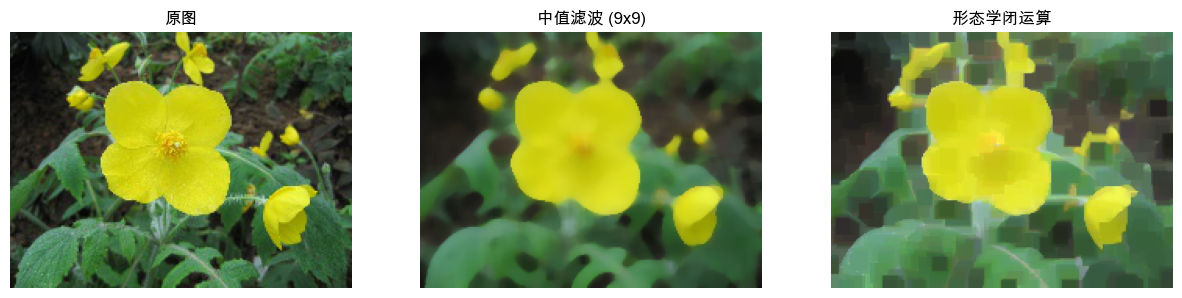

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
# 设置支持中文的字体
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'Microsoft YaHei', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

img = cv2.imread('image00.jpg', 1)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 使用中值滤波（类似效果，但快得多）
dst_median = cv2.medianBlur(img, 9)  # 9x9邻域中值滤波

# 使用形态学操作（另一种去噪方法）
kernel = np.ones((9, 9), np.uint8)
dst_morph = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)

# 显示对比
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('原图')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(dst_median, cv2.COLOR_BGR2RGB))
axes[1].set_title('中值滤波 (9x9)')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(dst_morph, cv2.COLOR_BGR2RGB))
axes[2].set_title('形态学闭运算')
axes[2].axis('off')
plt.show()

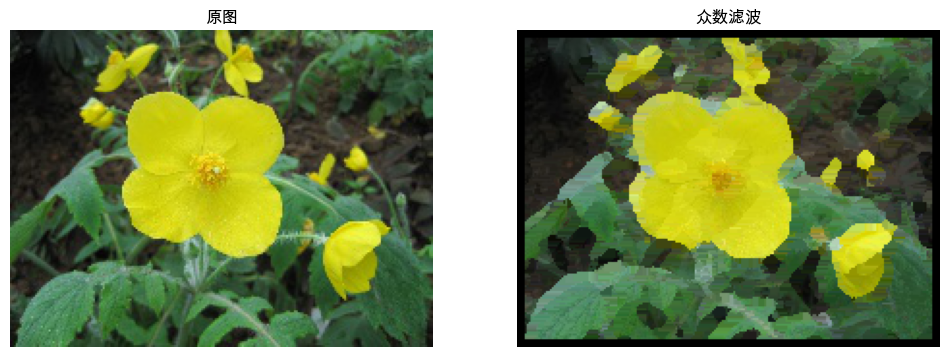

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('image00.jpg', 1)
height, width = img.shape[:2]
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
dst = np.zeros((height, width, 3), np.uint8)

for i in range(4, height-4):
    for j in range(4, width-4):
        # 统计8x8邻域的灰度直方图
        hist = np.zeros(8, np.int32)
        for m in range(-4, 4):
            for n in range(-4, 4):
                bin_idx = gray[i+m, j+n] // 32
                hist[bin_idx] += 1

        # 找到众数区间
        max_bin = np.argmax(hist)

        # 找到该区间内的第一个像素
        found = False
        for m in range(-4, 4):
            for n in range(-4, 4):
                if gray[i+m, j+n] // 32 == max_bin:
                    dst[i, j] = img[i+m, j+n]
                    found = True
                    break
            if found:
                break

# 显示
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('原图')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(dst, cv2.COLOR_BGR2RGB))
plt.title('众数滤波')
plt.axis('off')
plt.show()

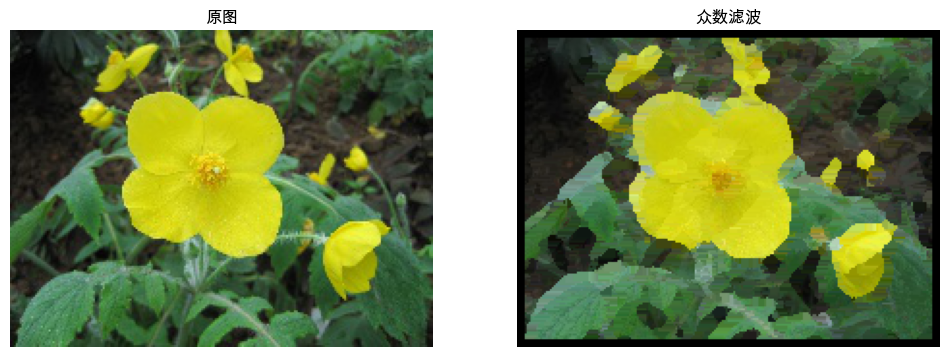

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('image00.jpg', 1)
height, width = img.shape[:2]
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
dst = np.zeros((height, width, 3), np.uint8)

for i in range(4, height-4):
    for j in range(4, width-4):
        # 统计8x8邻域的灰度直方图
        hist = np.zeros(8, np.int32)
        for m in range(-4, 4):
            for n in range(-4, 4):
                bin_idx = gray[i+m, j+n] // 32
                hist[bin_idx] += 1

        # 找到众数区间
        max_bin = np.argmax(hist)

        # 找到该区间内的第一个像素
        found = False
        for m in range(-4, 4):
            for n in range(-4, 4):
                if gray[i+m, j+n] // 32 == max_bin:
                    dst[i, j] = img[i+m, j+n]
                    found = True
                    break
            if found:
                break

# 显示
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('原图')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(dst, cv2.COLOR_BGR2RGB))
plt.title('众数滤波')
plt.axis('off')
plt.show()